# Figure 1 plot generator

This notebook generates every draft panel sketched in `plot_ideas/figure_1_idea.jpeg` and saves the outputs in `media/generated/figure_1/`.

The sparse-memory panels use the project model path (`models.load_session`, `models.MTL`, and `utils.py`). The spatial and receptive-field panels follow the track experiments from `lab_2.ipynb` and `lab_fig_c1.ipynb`, using the saved track autoencoder session plus `training.get_track_input` and `training.testing_mod`.

In [1]:
from pathlib import Path
import math
import os
import sys

os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/kamemory_mplconfig")
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)

import numpy as np
import torch
import matplotlib
if "ipykernel" not in sys.modules:
    matplotlib.use("Agg")
import matplotlib.pyplot as plt
from matplotlib import gridspec
from matplotlib.patches import Circle, Rectangle, FancyArrowPatch
from PIL import Image


def find_project_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    for path in [start, *start.parents]:
        if (path / "README.md").exists() and (path / "src").exists():
            return path
    raise RuntimeError("Could not find KAMemory project root")


ROOT = find_project_root()
sys.path.insert(0, str(ROOT / "src"))

import models
import training
import utils

OUTDIR = ROOT / "media" / "generated" / "figure_1"
OUTDIR.mkdir(parents=True, exist_ok=True)
IDEA_IMAGE = ROOT / "plot_ideas" / "figure_1_idea.jpeg"
AE_SESSION_NAME = "ae_8"
TRACK_SESSION_NAME = "ae_6"
SESSION_CACHE = {}

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.dpi": 120,
})

COLORS = {
    "ca3": "#202020",
    "ca1": "#202020",
    "ec": "#202020",
    "btsp": "#d83b36",
    "fixed": "#3a3a3a",
    "pretrained": "#2fa36b",
    "aligned": "#1f77b4",
    "random": "#b34a4a",
    "green": "#2fa36b",
}


def panel_label(ax, label):
    ax.text(-0.08, 1.06, label, transform=ax.transAxes, fontsize=18,
            fontweight="bold", va="bottom", ha="left")


MEDIA = ROOT / "media"
RASTER_EXTENSIONS = {".png", ".jpg", ".jpeg", ".webp", ".tif", ".tiff", ".bmp"}
REUSE_SAVED_PANELS = True
FORCE_REGENERATE_DATA = False
PANEL_PATHS = {}


def relative_path(path):
    path = Path(path)
    try:
        return path.relative_to(ROOT)
    except ValueError:
        return path


def media_image_candidates(name, aliases=()):
    wanted_names = {name, *[alias for alias in aliases if Path(alias).suffix]}
    wanted_stems = {Path(name).stem, *[Path(alias).stem for alias in aliases]}
    candidates = []
    for path in MEDIA.rglob("*"):
        if not path.is_file() or path.suffix.lower() not in RASTER_EXTENSIONS:
            continue
        if path.name in wanted_names or path.stem in wanted_stems:
            candidates.append(path)
    return candidates


def newest_media_image(name, aliases=()):
    candidates = media_image_candidates(name, aliases=aliases)
    if not candidates:
        return None
    return max(candidates, key=lambda path: (path.stat().st_mtime, str(path)))


def panel_image_available(name, aliases=()):
    return newest_media_image(name, aliases=aliases) is not None


def any_panel_missing(panel_specs):
    if FORCE_REGENERATE_DATA or not REUSE_SAVED_PANELS:
        return True
    return any(not panel_image_available(name, aliases) for name, aliases in panel_specs)


def show_saved_image(path):
    image = Image.open(path).convert("RGB")
    fig, ax = plt.subplots(figsize=(8, 8 * image.height / image.width))
    ax.imshow(image)
    ax.axis("off")
    print(f"showing saved {relative_path(path)}")
    return fig


def show_saved_or_generate(name, plotter, *args, aliases=(), **kwargs):
    if REUSE_SAVED_PANELS:
        path = newest_media_image(name, aliases=aliases)
        if path is not None:
            PANEL_PATHS[name] = path
            fig = show_saved_image(path)
            plt.show()
            plt.close(fig)
            return None, path

    fig = plotter(*args, **kwargs)
    plt.show()
    return fig, None


def save_panel(fig, name, outdir=OUTDIR):
    path = outdir / name
    fig.savefig(path, dpi=220, bbox_inches="tight", pad_inches=0.15, facecolor="white")
    plt.close(fig)
    PANEL_PATHS[name] = path
    print(f"saved {relative_path(path)}")
    return path


def save_panel_if_needed(fig, name, existing_path=None, outdir=OUTDIR):
    if existing_path is not None:
        PANEL_PATHS[name] = existing_path
        print(f"using existing {relative_path(existing_path)}")
        return existing_path
    if fig is None:
        path = newest_media_image(name)
        if path is None:
            raise FileNotFoundError(f"No generated figure or saved panel found for {name}")
        PANEL_PATHS[name] = path
        print(f"using existing {relative_path(path)}")
        return path
    return save_panel(fig, name, outdir=outdir)


def resolve_panel_image(name, aliases=()):
    path = PANEL_PATHS.get(name)
    if path is not None and Path(path).exists():
        return Path(path)
    path = newest_media_image(name, aliases=aliases)
    if path is None:
        raise FileNotFoundError(f"No saved image found for {name}; run and save its panel cell first.")
    PANEL_PATHS[name] = path
    return path


FIGURE_1_PANEL_SPECS = [
    ("panel_A_btsp_weight_change.png", ("weight_change_plot.png", "weight_kernel_a.png")),
    ("panel_B_kernel_fixed_points.png", ("sim_plot.png", "descr_plot.png")),
    ("panel_C_learning_dynamics.png", ("loss_stimuli_a.png", "loss_stimuli_mtl.png", "loss_stimuli_rnd.png")),
    ("panel_D_architecture.png", ("architecture_a.png", "pc_gc.png")),
    ("panel_E_receptive_field_formation.png", ("pc_moving_a.png", "pc_moving_b.png", "pc_moving_c.png", "pc_moving_d.png", "pc_moving_e.png")),
    ("panel_F_space_sensory_input.png", ("ec_pattern_b.png", "exp_protocol_a.png", "exp_protocol_b.png")),
    ("panel_G_memory_decodability.png", ("diagram_reconstruction_a.png",)),
    ("panel_H_decoded_pattern_examples.png", ("reconstruction_a.png", "reconstruction_d.png", "reconstruction_d2.png", "reconstruction.png")),
    ("panel_I_decodability_quantification.png", ("accuracy_a.png", "accuracy_0.png", "accuracy_1.png", "accuracy_matrix.png", "capacity_0.png", "capacity_1.png")),
]
SPARSE_DATA_PANEL_SPECS = [FIGURE_1_PANEL_SPECS[i] for i in (2, 7, 8)]
TRACK_DATA_PANEL_SPECS = [FIGURE_1_PANEL_SPECS[i] for i in (4, 5)]

def load_project_session(session_name=AE_SESSION_NAME):
    if session_name not in SESSION_CACHE:
        sessions = [name for name in os.listdir(utils.AE_PATH) if "ae" in name]
        if session_name not in sessions:
            available = ", ".join(sorted(sessions))
            raise ValueError(f"Autoencoder session {session_name!r} not found. Available: {available}")
        SESSION_CACHE[session_name] = models.load_session(idx=sessions.index(session_name), verbose=False)
    return SESSION_CACHE[session_name]


def session_network_params(info):
    if "network_params" in info:
        params = dict(info["network_params"])
        return params
    return {
        "dim_ei": int(info["dim_ei"]),
        "dim_eo": int(info.get("dim_eo", info["dim_ei"])),
        "dim_ca1": int(info["dim_ca1"]),
        "dim_ca3": int(info["dim_ca3"]),
        "K_ei": int(info["K"]),
        "K_eo": int(info["K"]),
        "K_ca1": int(info["K_lat"]),
        "K_ca3": min(22, int(info["dim_ca3"])),
        "beta_ca1": float(info["beta"]),
        "bias": bool(info.get("bias", True)),
        "alpha": 0.35,
    }


def set_seeds(seed):
    np.random.seed(seed)
    torch.manual_seed(seed)


def as_column(x):
    return torch.tensor(np.asarray(x).reshape(-1, 1), dtype=torch.float32)


def tensor_to_numpy(x):
    return x.detach().cpu().numpy().reshape(-1)


def project_sparsemoid_column(x, k, beta):
    return utils.sparsemoid(x.reshape(1, -1), K=int(k), beta=float(beta)).reshape(-1, 1)


def project_cosine(x, y):
    return float(utils.cosine_similarity_vec(x, y).item())


def place_field_activity(n_x, sigma, xi):
    return utils.place_field_activity(N_x=n_x, N_y=1, sigma=sigma, xi=xi, yi=0).reshape(-1)


def configure_recording(model, mode="none"):
    if mode == "none":
        model.record = lambda x_ei, IS: None
        return model
    if mode != "activity":
        raise ValueError(f"Unknown recording mode: {mode}")

    model.recordings = {"x_ei": [], "ca3": [], "ca1": [], "eo": [], "IS": []}

    def record_activity(x_ei, IS):
        model.recordings["x_ei"].append(x_ei.detach().clone())
        model.recordings["ca3"].append(model._ca3.detach().clone())
        model.recordings["ca1"].append(model._ca1.detach().clone())
        model.recordings["eo"].append(model._eo.detach().clone())
        model.recordings["IS"].append(IS.detach().clone())

    model.record = record_activity
    return model


def make_mtl_model(info, autoencoder, alpha=None, k_ca3=None,
                   shuffle_fraction=0.0, record_mode="none"):
    params = session_network_params(info)
    alpha = params.get("alpha", 0.35) if alpha is None else alpha
    k_ca3 = params.get("K_ca3", min(22, params["dim_ca3"])) if k_ca3 is None else k_ca3

    w_ei_ca1, w_ca1_eo, b_ei_ca1, b_ca1_eo = autoencoder.get_weights(bias=bool(params.get("bias", True)))
    base_w_ei_ca1 = w_ei_ca1.clone().detach()
    base_b_ei_ca1 = b_ei_ca1.clone().detach() if b_ei_ca1 is not None else torch.zeros(w_ei_ca1.shape[0], 1)

    model = models.MTL(
        W_ei_ca1=w_ei_ca1.clone().detach(),
        W_ca1_eo=w_ca1_eo.clone().detach(),
        B_ei_ca1=base_b_ei_ca1.clone().detach(),
        B_ca1_eo=b_ca1_eo.clone().detach() if b_ca1_eo is not None else None,
        dim_ca3=int(params["dim_ca3"]),
        K_lat=int(params["K_ca1"]),
        K_out=int(params["K_eo"]),
        K_ca3=int(k_ca3),
        beta=float(params["beta_ca1"]),
        alpha=float(alpha),
    )

    n_shuffle = int(round(float(shuffle_fraction) * model.W_ei_ca1.shape[0]))
    if n_shuffle > 1:
        rows = torch.randperm(model.W_ei_ca1.shape[0])[:n_shuffle]
        permuted = rows[torch.randperm(len(rows))]
        with torch.no_grad():
            model.W_ei_ca1.data[rows] = model.W_ei_ca1.data[permuted].clone()

    configure_recording(model, mode=record_mode)
    return model, base_w_ei_ca1, base_b_ei_ca1


def run_memory(seed=1, n_patterns=30, alpha=0.35, shuffle_fraction=0.0,
               session_name=AE_SESSION_NAME, k_ca3=22):
    set_seeds(seed)
    info, autoencoder = load_project_session(session_name=session_name)
    params = session_network_params(info)
    model, base_w_ei_ca1, base_b_ei_ca1 = make_mtl_model(
        info=info,
        autoencoder=autoencoder,
        alpha=alpha,
        k_ca3=k_ca3,
        shuffle_fraction=shuffle_fraction,
        record_mode="none",
    )

    samples = utils.sparse_stimulus_generator(N=n_patterns, K=int(params["K_ei"]), size=int(params["dim_ei"]))
    accuracy = np.full((n_patterns, n_patterns), np.nan)
    final_outputs = []
    alignments = []
    ca1_snapshots = []

    with torch.no_grad():
        for i, x_np in enumerate(samples):
            x = as_column(x_np)
            true_is = project_sparsemoid_column(
                base_w_ei_ca1 @ x + base_b_ei_ca1,
                params["K_ca1"],
                params["beta_ca1"],
            )
            used_is = project_sparsemoid_column(
                model.W_ei_ca1 @ x + model.B_ei_ca1,
                params["K_ca1"],
                params["beta_ca1"],
            )
            alignments.append(project_cosine(true_is, used_is))

            model.resume_lr()
            _ = model(x)
            model.pause_lr()

            for j, x_j_np in enumerate(samples[:i + 1]):
                x_j = as_column(x_j_np)
                y_j = model(x_j)
                accuracy[i, j] = project_cosine(x_j, y_j)

            if i in {4, 14, n_patterns - 1}:
                ca1_snapshots.append((i, model.W_ca3_ca1.detach().cpu().numpy().copy()))

        model.pause_lr()
        for x_j_np in samples:
            y_j = model(as_column(x_j_np))
            final_outputs.append(tensor_to_numpy(y_j))

    return {
        "info": info,
        "params": params,
        "model": model,
        "autoencoder_session": session_name,
        "samples": samples,
        "accuracy": accuracy,
        "final_outputs": np.array(final_outputs),
        "alignment": float(np.mean(alignments)),
        "ca1_snapshots": ca1_snapshots,
        "w_ca3_ca1": model.W_ca3_ca1.detach().cpu().numpy().copy(),
    }


def recordings_to_array(model, region, track_params):
    rows = [tensor_to_numpy(x) for x in model.recordings[region]]
    return np.array(rows).reshape((track_params["num_laps"], track_params["length"], -1))


def summarize_track_activity(model, track_params, params, lap_cues, top_k=8):
    num_cues = int(params["num_cues"])
    laps_data = {region: {cue: {} for cue in range(num_cues)} for region in model.recordings.keys()}
    for cue in range(num_cues):
        cue_pos = int(track_params["cue_position"][cue])
        cue_laps = np.where(lap_cues == cue)[0]
        for region in model.recordings.keys():
            activity = recordings_to_array(model, region, track_params)
            activity_when_cue = np.mean(activity[cue_laps], axis=0)
            avg_activity = activity_when_cue.mean(axis=0) + 1e-9
            sensitivity = activity_when_cue[cue_pos] / avg_activity
            laps_data[region][cue]["activity"] = activity_when_cue
            laps_data[region][cue]["sensitivity"] = sensitivity
            laps_data[region][cue]["top"] = np.argsort(sensitivity)[-top_k:]

    same_rows = []
    opposite_rows = []
    for cue in range(num_cues):
        other = (cue + 1) % num_cues
        idxs = laps_data["IS"][cue]["top"]
        same_rows.append(laps_data["ca1"][cue]["activity"][:, idxs].T)
        opposite_rows.append(laps_data["ca1"][other]["activity"][:, idxs].T)

    same_cue = np.vstack(same_rows)
    opposite_cue = np.vstack(opposite_rows)
    return {
        "laps_data": laps_data,
        "same_cue": same_cue,
        "opposite_cue": opposite_cue,
        "difference": same_cue - opposite_cue,
    }


def run_track_demo(seed=22, session_name=TRACK_SESSION_NAME, num_laps=16,
                   cue_positions=(10, 30), alpha_baseline=0.1):
    set_seeds(seed)
    info, autoencoder = load_project_session(session_name=session_name)
    params = session_network_params(info)
    params = dict(params)
    params["num_cues"] = len(cue_positions)
    params["alpha"] = float(params.get("alpha", 0.5))

    track_params = {
        "length": int(params["mec_N_x"]),
        "num_laps": int(num_laps),
        "reward": "random",
        "cue": "random",
        "cue_position": list(cue_positions),
    }
    track_input, lap_cues, alpha_samples = training.get_track_input(
        track_params=track_params,
        network_params=params,
        cue_duration=1,
    )

    model, _, _ = make_mtl_model(
        info=info,
        autoencoder=autoencoder,
        alpha=params["alpha"],
        k_ca3=params["K_ca3"],
        shuffle_fraction=0.0,
        record_mode="activity",
    )
    loss, model = training.testing_mod(
        data=track_input,
        model=model,
        alpha_samples=alpha_samples,
        alpha_baseline=alpha_baseline,
        column=True,
    )
    summary = summarize_track_activity(model, track_params, params, lap_cues)
    return {
        "info": info,
        "params": params,
        "track_params": track_params,
        "track_input": track_input,
        "lap_cues": lap_cues,
        "alpha_samples": alpha_samples,
        "model": model,
        "loss": float(loss.detach().cpu().item() if hasattr(loss, "detach") else loss),
        "summary": summary,
    }


def retention_curve(accuracy):
    n = accuracy.shape[0]
    means = []
    sems = []
    for age in range(n):
        vals = []
        for step in range(n):
            j = step - age
            if j >= 0 and not np.isnan(accuracy[step, j]):
                vals.append(accuracy[step, j])
        vals = np.array(vals)
        means.append(np.nanmean(vals))
        sems.append(np.nanstd(vals) / np.sqrt(max(1, len(vals))))
    return np.arange(n), np.array(means), np.array(sems)


## Run memory simulations

The aligned condition uses the CA1 content code as the instructive signal. The shuffled condition permutes CA1 rows in the instructive-signal encoder, breaking the alignment between the IS and the fixed CA1 decoder.

In [2]:
if any_panel_missing(SPARSE_DATA_PANEL_SPECS):
    aligned = run_memory(seed=12, n_patterns=30, alpha=0.35, shuffle_fraction=0.0)
    shuffled = run_memory(seed=12, n_patterns=30, alpha=0.35, shuffle_fraction=1.0)

    np.savez(
        OUTDIR / "figure_1_simulation.npz",
        aligned_accuracy=aligned["accuracy"],
        shuffled_accuracy=shuffled["accuracy"],
        aligned_samples=aligned["samples"],
        shuffled_outputs=shuffled["final_outputs"],
        aligned_outputs=aligned["final_outputs"],
        aligned_alignment=aligned["alignment"],
        shuffled_alignment=shuffled["alignment"],
    )
    print("aligned final mean decodability:", np.nanmean(aligned["accuracy"][-1]))
    print("shuffled final mean decodability:", np.nanmean(shuffled["accuracy"][-1]))
else:
    aligned = None
    shuffled = None
    print("sparse memory simulation skipped; saved panel images are available")


2026-06-02 18:21:00 | bias not found in the info file, set to True


aligned final mean decodability: 0.5944839134812355
shuffled final mean decodability: 0.1277210819520794


## Run track simulation

This reproduces the spatial/sensory setup used in `lab_2.ipynb` and `lab_fig_c1.ipynb` with the saved track autoencoder session.

In [3]:
if any_panel_missing(TRACK_DATA_PANEL_SPECS):
    track_demo = run_track_demo(seed=22, num_laps=16, cue_positions=(10, 30))
    np.savez(
        OUTDIR / "figure_1_track_demo.npz",
        track_input=track_demo["track_input"],
        lap_cues=track_demo["lap_cues"],
        alpha_samples=track_demo["alpha_samples"],
        ca1_same_cue=track_demo["summary"]["same_cue"],
        ca1_opposite_cue=track_demo["summary"]["opposite_cue"],
        ca1_difference=track_demo["summary"]["difference"],
    )
    print("track loss:", track_demo["loss"])
    print("track input shape:", track_demo["track_input"].shape)
else:
    track_demo = None
    print("track simulation skipped; saved panel images are available")


2026-06-02 18:21:04 | testing...
100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 800/800 [00:01<00:00, 500.60it/s]

track loss: 0.08279650658369064
track input shape: (800, 100)


## A. BTSP-induced weight change

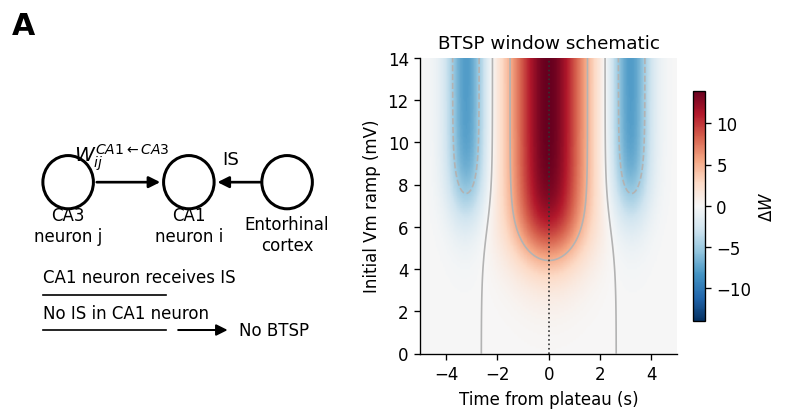

In [4]:
def plot_panel_a():
    t = np.linspace(-6, 6, 700)
    v = np.linspace(-4, 4, 700)
    plasticity = np.exp(-(t / 1.7) ** 2) * np.tanh(1.2 * v)
    ltd = -0.45 * np.exp(-((t + 2.2) / 1.1) ** 2) * np.exp(-((v + 1.4) / 1.6) ** 2)
    ltp = 0.70 * np.exp(-((t - 0.6) / 1.4) ** 2) * np.exp(-((v - 1.2) / 1.8) ** 2)
    surface = plasticity + ltd + ltp

    fig, ax = plt.subplots(figsize=(5.2, 3.4))
    panel_label(ax, "A")
    ax.plot(t, surface[350], color=COLORS["btsp"], lw=2.5)
    ax.fill_between(t, 0, surface[350], where=surface[350] >= 0, color=COLORS["btsp"], alpha=0.25)
    ax.fill_between(t, 0, surface[350], where=surface[350] < 0, color="gray", alpha=0.25)
    ax.axhline(0, color="black", lw=0.8)
    ax.axvline(0, color="black", lw=0.8, ls="--")
    ax.set_xlabel("time from plateau potential")
    ax.set_ylabel("synaptic weight change")
    ax.set_title("BTSP kernel", fontsize=12)
    return fig

fig_panel_a, panel_a_path = show_saved_or_generate(
    "panel_A_btsp_weight_change.png",
    plot_panel_a,
    aliases=("weight_change_plot.png", "weight_kernel_a.png"),
)


In [ ]:
panel_a_path = save_panel_if_needed(fig_panel_a, "panel_A_btsp_weight_change.png", panel_a_path)


## B. Kernel fixed points

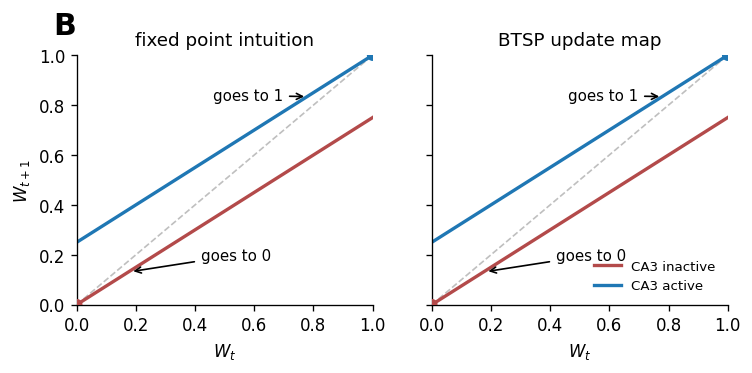

In [5]:
def plot_panel_b():
    fig, axes = plt.subplots(1, 2, figsize=(7.0, 2.7), sharey=True)
    panel_label(axes[0], "B")
    w = np.linspace(0, 1, 200)
    alpha = 0.25
    maps = {
        "inactive CA3": (1 - alpha) * w,
        "active CA3": (1 - alpha) * w + alpha,
    }

    for ax, title in zip(axes, ["fixed point intuition", "BTSP update map"]):
        ax.plot(w, w, color="0.75", lw=1, ls="--")
        ax.plot(w, maps["inactive CA3"], color=COLORS["random"], lw=2, label="CA3 inactive")
        ax.plot(w, maps["active CA3"], color=COLORS["aligned"], lw=2, label="CA3 active")
        ax.scatter([0, 1], [0, 1], s=35, color=["#b34a4a", "#1f77b4"], zorder=3)
        ax.annotate("goes to 0", xy=(0.18, maps["inactive CA3"][35]), xytext=(0.42, 0.18),
                    arrowprops=dict(arrowstyle="->", lw=1), fontsize=9)
        ax.annotate("goes to 1", xy=(0.78, maps["active CA3"][155]), xytext=(0.46, 0.82),
                    arrowprops=dict(arrowstyle="->", lw=1), fontsize=9)
        ax.set_xlabel(r"$W_t$")
        ax.set_title(title, fontsize=11)
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
    axes[0].set_ylabel(r"$W_{t+1}$")
    axes[1].legend(frameon=False, loc="lower right", fontsize=8)
    return fig

fig_panel_b, panel_b_path = show_saved_or_generate(
    "panel_B_kernel_fixed_points.png",
    plot_panel_b,
    aliases=("sim_plot.png", "descr_plot.png"),
)


In [ ]:
panel_b_path = save_panel_if_needed(fig_panel_b, "panel_B_kernel_fixed_points.png", panel_b_path)


## C. Learning dynamics

In [ ]:
def plot_panel_c():
    fig, ax = plt.subplots(figsize=(4.4, 3.3))
    ax.set_axis_off()
    panel_label(ax, "C")
    ax.text(0.05, 0.93, "learning dynamics", fontsize=12, ha="left")
    ax.plot([0.05, 0.55], [0.89, 0.89], color="black", lw=1)
    ax.text(0.05, 0.67, r"$W^{CA1 \leftarrow CA3}(t+1) =$", fontsize=15)
    ax.text(0.12, 0.52, r"$(1-\alpha IS^{CA1})W^{CA1 \leftarrow CA3}(t)$", fontsize=15)
    ax.text(0.12, 0.37, r"$+\alpha IS^{CA1}(X^{CA3})^T$", fontsize=15)
    ax.text(
        0.05, 0.10,
        "If IS is 0, previous weights remain.\n"
        "If IS is 1, CA3-active weights converge to 1\n"
        "and CA3-inactive weights converge to 0.",
        fontsize=10,
        va="bottom",
    )
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    return fig

fig_panel_c, panel_c_path = show_saved_or_generate(
    "panel_C_learning_dynamics.png",
    plot_panel_c,
    aliases=("loss_stimuli_a.png", "loss_stimuli_mtl.png", "loss_stimuli_rnd.png"),
)


In [ ]:
panel_c_path = save_panel_if_needed(fig_panel_c, "panel_C_learning_dynamics.png", panel_c_path)


## D. Architecture

In [ ]:
def draw_node(ax, xy, label):
    circ = Circle(xy, 0.12, fill=False, lw=2.2, color="black")
    ax.add_patch(circ)
    ax.text(*xy, label, ha="center", va="center", fontsize=12)


def draw_arrow(ax, start, end, color="black", lw=2, style="-|>", ls="-", text=None, text_xy=None):
    ax.add_patch(FancyArrowPatch(start, end, arrowstyle=style, mutation_scale=15,
                                 lw=lw, color=color, linestyle=ls))
    if text:
        ax.text(*text_xy, text, fontsize=9, ha="center", va="center", color=color)


def plot_panel_d():
    fig, ax = plt.subplots(figsize=(4.8, 3.5))
    ax.set_axis_off()
    panel_label(ax, "D")
    ax.text(0.50, 0.95, "Architecture", ha="center", va="top", fontsize=14, fontweight="bold")

    pos = {"CA3": (0.28, 0.62), "CA1": (0.63, 0.62), "ECin": (0.28, 0.24), "ECout": (0.63, 0.24)}
    for label, xy in pos.items():
        draw_node(ax, xy, label.replace("ECin", "EC(in)").replace("ECout", "EC(out)"))
    draw_arrow(ax, (0.40, 0.62), (0.51, 0.62), color=COLORS["btsp"], lw=2.2)
    draw_arrow(ax, (0.28, 0.36), (0.28, 0.50), color=COLORS["fixed"], lw=1.7, ls=":")
    draw_arrow(ax, (0.38, 0.30), (0.53, 0.52), color=COLORS["pretrained"], lw=1.7, ls=":")
    draw_arrow(ax, (0.63, 0.50), (0.63, 0.36), color=COLORS["pretrained"], lw=1.9, ls=":")
    ax.add_patch(Rectangle((0.42, 0.38), 0.13, 0.08, fill=False, lw=1.5))
    ax.text(0.485, 0.42, "IS", ha="center", va="center", fontsize=11)

    ax.plot([0.82, 0.96], [0.78, 0.78], color=COLORS["fixed"], lw=1.8, ls=":")
    ax.text(0.98, 0.78, "fixed random", va="center", fontsize=9)
    ax.plot([0.82, 0.96], [0.66, 0.66], color=COLORS["pretrained"], lw=1.8, ls=":")
    ax.text(0.98, 0.66, "fixed pre-trained", va="center", fontsize=9)
    ax.plot([0.82, 0.96], [0.54, 0.54], color=COLORS["btsp"], lw=2.2)
    ax.text(0.98, 0.54, "BTSP", va="center", fontsize=9)
    ax.set_xlim(0, 1.15)
    ax.set_ylim(0, 1)
    return fig

fig_panel_d, panel_d_path = show_saved_or_generate(
    "panel_D_architecture.png",
    plot_panel_d,
    aliases=("architecture_a.png", "pc_gc.png"),
)


In [ ]:
panel_d_path = save_panel_if_needed(fig_panel_d, "panel_D_architecture.png", panel_d_path)


## E. Receptive field formation

In [ ]:
def plot_panel_e(track):
    summary = track["summary"]
    fig, axes = plt.subplots(3, 1, figsize=(5.4, 4.7), sharex=True)
    panel_label(axes[0], "E")
    panels = [
        (summary["same_cue"], "CA1 activity, cue-matched laps", "hot", 0, 1),
        (summary["opposite_cue"], "same neurons, opposite cue laps", "hot", 0, 1),
        (summary["difference"], "cue preference difference", "RdBu_r", -1, 1),
    ]
    for ax, (mat, title, cmap, vmin, vmax) in zip(axes, panels):
        im = ax.imshow(mat, aspect="auto", cmap=cmap, interpolation="nearest", vmin=vmin, vmax=vmax)
        for cuex in track["track_params"]["cue_position"]:
            ax.axvline(cuex, color=COLORS["green"], lw=1.5, alpha=0.65)
        ax.set_ylabel("CA1\nneurons", rotation=0, ha="right", va="center", labelpad=38)
        ax.set_yticks([])
        ax.set_title(title, fontsize=10)
    axes[-1].set_xlabel("position on track")
    axes[-1].set_xticks([0, *track["track_params"]["cue_position"], track["track_params"]["length"] - 1])
    axes[-1].set_xticklabels([0, *track["track_params"]["cue_position"], track["track_params"]["length"]])
    fig.colorbar(im, ax=axes, shrink=0.72, label="activity / difference")
    return fig

fig_panel_e, panel_e_path = show_saved_or_generate(
    "panel_E_receptive_field_formation.png",
    plot_panel_e,
    track_demo,
    aliases=("pc_moving_a.png", "pc_moving_b.png", "pc_moving_c.png", "pc_moving_d.png", "pc_moving_e.png"),
)


In [ ]:
panel_e_path = save_panel_if_needed(fig_panel_e, "panel_E_receptive_field_formation.png", panel_e_path)


## F. Spatial and sensory input

In [ ]:
def plot_panel_f(track):
    params = track["params"]
    cue_index = int(np.nanargmax(track["alpha_samples"]))
    sample = track["track_input"][cue_index]
    space = sample[:params["dim_mec"]].reshape(params["mec_N_y"], params["mec_N_x"])
    sensory = sample[params["dim_mec"]:]

    fig, axes = plt.subplots(2, 1, figsize=(4.6, 2.4), sharex=True)
    panel_label(axes[0], "F")
    axes[0].imshow(space, cmap="gray_r", aspect="auto", vmin=0, vmax=1)
    axes[0].set_title("space", fontsize=12)
    axes[1].imshow(sensory.reshape(1, -1), cmap="gray_r", aspect="auto", vmin=0, vmax=1)
    axes[1].set_title("sensory", fontsize=12)
    for ax in axes:
        ax.set_yticks([])
        ax.set_xticks([])
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_linewidth(1)
    return fig

fig_panel_f, panel_f_path = show_saved_or_generate(
    "panel_F_space_sensory_input.png",
    plot_panel_f,
    track_demo,
    aliases=("ec_pattern_b.png", "exp_protocol_a.png", "exp_protocol_b.png"),
)


In [ ]:
panel_f_path = save_panel_if_needed(fig_panel_f, "panel_F_space_sensory_input.png", panel_f_path)


## G. Memory decodability schematic

In [ ]:
def plot_panel_g():
    fig, ax = plt.subplots(figsize=(4.8, 3.0))
    ax.set_axis_off()
    panel_label(ax, "G")
    ax.text(0.50, 0.94, "memory decodability", ha="center", fontsize=12)
    ax.text(0.25, 0.75, "encoding", ha="center", fontsize=11)
    ax.text(0.73, 0.75, "recall", ha="center", fontsize=11)
    ax.text(0.25, 0.58, "pattern of ECin", ha="center")
    ax.text(0.25, 0.28, r"$W^{CA1 \leftarrow CA3}$", ha="center")
    ax.text(0.73, 0.58, "pattern of ECin", ha="center")
    ax.text(0.73, 0.28, "pattern of ECout", ha="center")
    ax.add_patch(FancyArrowPatch((0.25, 0.52), (0.25, 0.36), arrowstyle="-|>", mutation_scale=14, lw=1.4))
    ax.add_patch(FancyArrowPatch((0.73, 0.36), (0.73, 0.52), arrowstyle="-|>", mutation_scale=14, lw=1.4))
    ax.text(0.86, 0.45, "cosine\nsimilarity", ha="center", va="center")
    ax.plot([0.80, 0.80], [0.30, 0.62], color="black", lw=1)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    return fig

fig_panel_g, panel_g_path = show_saved_or_generate(
    "panel_G_memory_decodability.png",
    plot_panel_g,
    aliases=("diagram_reconstruction_a.png",),
)


In [ ]:
panel_g_path = save_panel_if_needed(fig_panel_g, "panel_G_memory_decodability.png", panel_g_path)


## H. Example decoded patterns

In [ ]:
def plot_panel_h(record):
    n_show = 6
    fig, axes = plt.subplots(3, 1, figsize=(6.5, 3.2), sharex=True)
    panel_label(axes[0], "H")
    matrices = [
        (record["samples"][:n_show], "ECin patterns"),
        (record["final_outputs"][:n_show], "ECout recall"),
        (np.abs(record["samples"][:n_show] - record["final_outputs"][:n_show]), "absolute error"),
    ]
    for ax, (mat, label) in zip(axes, matrices):
        cmap = "gray_r" if label != "absolute error" else "magma"
        ax.imshow(mat, aspect="auto", cmap=cmap, vmin=0, vmax=1)
        ax.set_ylabel(label, rotation=0, ha="right", va="center", labelpad=55)
        ax.set_yticks(range(n_show))
        ax.set_yticklabels(range(1, n_show + 1), fontsize=8)
        ax.set_xticks([])
    axes[-1].set_xlabel("EC unit")
    return fig

fig_panel_h, panel_h_path = show_saved_or_generate(
    "panel_H_decoded_pattern_examples.png",
    plot_panel_h,
    aligned,
    aliases=("reconstruction_a.png", "reconstruction_d.png", "reconstruction_d2.png", "reconstruction.png"),
)


In [ ]:
panel_h_path = save_panel_if_needed(fig_panel_h, "panel_H_decoded_pattern_examples.png", panel_h_path)


## I. Quantifying decodability

In [ ]:
def plot_panel_i(aligned, shuffled):
    fig = plt.figure(figsize=(7.8, 3.6))
    gs = gridspec.GridSpec(1, 2, width_ratios=[1.0, 1.15], wspace=0.35)
    ax0 = fig.add_subplot(gs[0, 0])
    panel_label(ax0, "I")
    matrix = np.ma.masked_invalid(aligned["accuracy"])
    im = ax0.imshow(matrix, origin="lower", cmap="viridis", vmin=0, vmax=1, aspect="auto")
    ax0.set_xlabel("memory index")
    ax0.set_ylabel("last stored pattern")
    ax0.set_title("recall quality matrix", fontsize=11)
    cbar = fig.colorbar(im, ax=ax0, shrink=0.8)
    cbar.set_label("cosine similarity")

    ax1 = fig.add_subplot(gs[0, 1])
    for rec, label, color in [
        (aligned, "content-aware IS", COLORS["aligned"]),
        (shuffled, "shuffled IS", COLORS["random"]),
    ]:
        age, mean, sem = retention_curve(rec["accuracy"])
        ax1.plot(age, mean, color=color, lw=2, label=label)
        ax1.fill_between(age, mean - sem, mean + sem, color=color, alpha=0.18, lw=0)
    ax1.set_xlabel("# patterns stored afterwards")
    ax1.set_ylabel("decodability")
    ax1.set_ylim(0, 1.02)
    ax1.set_title("quality decay", fontsize=11)
    ax1.legend(frameon=False, fontsize=9)
    return fig

fig_panel_i, panel_i_path = show_saved_or_generate(
    "panel_I_decodability_quantification.png",
    plot_panel_i,
    aligned,
    shuffled,
    aliases=("accuracy_a.png", "accuracy_0.png", "accuracy_1.png", "accuracy_matrix.png", "capacity_0.png", "capacity_1.png"),
)


In [ ]:
panel_i_path = save_panel_if_needed(fig_panel_i, "panel_I_decodability_quantification.png", panel_i_path)


## Assemble draft Figure 1

In [ ]:
def assemble_composite(panel_specs, ncols=2):
    panel_paths = [resolve_panel_image(name, aliases=aliases) for name, aliases in panel_specs]
    images = [Image.open(path).convert("RGB") for path in panel_paths]
    widths, heights = zip(*(im.size for im in images))
    cell_w = max(widths)
    cell_h = max(heights)
    nrows = math.ceil(len(images) / ncols)
    canvas = Image.new("RGB", (cell_w * ncols, cell_h * nrows), "white")
    for idx, im in enumerate(images):
        r, c = divmod(idx, ncols)
        x = c * cell_w + (cell_w - im.size[0]) // 2
        y = r * cell_h + (cell_h - im.size[1]) // 2
        canvas.paste(im, (x, y))
    print("composite panel sources:")
    for path in panel_paths:
        print(f"- {relative_path(path)}")
    return canvas


figure_composite_image = assemble_composite(FIGURE_1_PANEL_SPECS, ncols=2)
figure_composite_preview, figure_composite_ax = plt.subplots(
    figsize=(10, 10 * figure_composite_image.height / figure_composite_image.width)
)
figure_composite_ax.imshow(figure_composite_image)
figure_composite_ax.axis("off")
plt.show()


In [ ]:
out = OUTDIR / "figure_1_composite.png"
figure_composite_image.save(out)
print(f"saved {out.relative_to(ROOT)}")